In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
import seaborn as sns
import casadi as ca

## Parámetros del sistema y configuración de simulación

In [2]:
# Tank cross-sectional areas [cm^2]
A1, A3 = 28.0, 28.0
A2, A4 = 32.0, 32.0

# Outlet orifice areas [cm^2]
a1, a3 = 0.071, 0.071
a2, a4 = 0.057, 0.057

# Pump flow constants [cm^3/Vs]
k1, k2 = 3.33, 3.35

# Flow division parameters between upper and lower tanks
gamma1, gamma2 = 0.70, 0.60

# Constant gravitational acceleration [cm/s^2]
g = 981.0

# Time configuration and integration step
dt = 0.05
T_sim = 5000
t = np.arange(0, T_sim + dt, dt)
n = len(t)

# Initial conditions for the levels of the four tanks [cm]
h0 = np.array([12.4, 12.7, 1.8, 1.4])

# Standard deviation of Gaussian noise for inputs and outputs
noise_input_std = 0.1
noise_output_std = 0.1

# Duration of steps for the excitation signal
t_change_min = 50
t_change_max = 50

# Voltage operating limits for the water pumps
V_min = 0.0
V_max = 6.0

## Función del sistema dinámico no lineal de cuatro tanques

El sistema se describe mediante el siguiente conjunto de ecuaciones acopladas:

$$\frac{dh_1}{dt} = -\frac{a_1}{A_1} \sqrt{2gh_1} + \frac{a_3}{A_1} \sqrt{2gh_3} + \frac{\gamma_1 k_1}{A_1} v_1$$
$$\frac{dh_2}{dt} = -\frac{a_2}{A_2} \sqrt{2gh_2} + \frac{a_4}{A_2} \sqrt{2gh_4} + \frac{\gamma_2 k_2}{A_2} v_2$$
$$\frac{dh_3}{dt} = -\frac{a_3}{A_3} \sqrt{2gh_3} + \frac{(1 - \gamma_2) k_2}{A_3} v_2$$
$$\frac{dh_4}{dt} = -\frac{a_4}{A_4} \sqrt{2gh_4} + \frac{(1 - \gamma_1) k_1}{A_4} v_1$$


In [3]:
def nonlinear_ode_system_model(t, h, u_func, A1, A2, A3, A4, a1, a2, a3, a4, g, k1, k2, gamma1, gamma2):
    # Unpack levels for the four tanks
    h1, h2, h3, h4 = h
    eps = 1e-6

    # Numerical protection to avoid square roots of negative values
    h_safe = np.maximum(h, eps)
    h1_s, h2_s, h3_s, h4_s = h_safe

    # Get input voltages at time t
    v1, v2 = u_func(t)

    # Mass balance for lower tanks with inflow from upper tanks
    dh1dt = -(a1 / A1) * np.sqrt(2 * g * h1_s) + (a3 / A1) * np.sqrt(2 * g * h3_s) + (gamma1 * k1 / A1) * v1
    dh2dt = -(a2 / A2) * np.sqrt(2 * g * h2_s) + (a4 / A2) * np.sqrt(2 * g * h4_s) + (gamma2 * k2 / A2) * v2

    # Mass balance for upper tanks fed by divided flow
    dh3dt = -(a3 / A3) * np.sqrt(2 * g * h3_s) + ((1 - gamma2) * k2 / A3) * v2
    dh4dt = -(a4 / A4) * np.sqrt(2 * g * h4_s) + ((1 - gamma1) * k1 / A4) * v1

    # Return state derivatives for the integrator
    return [dh1dt, dh2dt, dh3dt, dh4dt]

## Creación de señales PBRS de entrada

In [4]:
# Random number generator configuration with a fixed seed
seed_stream = 100
rng_stream = np.random.Generator(np.random.MT19937(seed_stream))

# Initialization of indexes for signal level changes
t_change_indexes = []
curr_idx = 0

# Generation of random duration intervals for the steps
while curr_idx < n:
    t_change_indexes.append(curr_idx)

    # Calculation of step duration in seconds and its equivalent in steps
    duration_seg = rng_stream.uniform(t_change_min, t_change_max)
    step_sequences = int(duration_seg / dt)
    curr_idx += step_sequences

# Generation of random amplitudes for the voltages of both pumps
steps_values = rng_stream.uniform(V_min, V_max, size=(len(t_change_indexes), 2))

## Construcción de la señal de entrada y adición de ruido

La señal de entrada final se modela como:
$$u_{real}(t) = \text{sat}_{V_{min}}^{V_{max}} \{ u_{ideal}(t) + \eta_u(t) \}$$

In [5]:
# Initialization of the matrix for the ideal input signal (no noise)
u_ideal = np.zeros((n, 2))

# Construction of the piecewise constant signal based on change indexes
for i in range(len(t_change_indexes)):
    idx_start = t_change_indexes[i]

    # Definition of the upper limit for the current interval
    if i == len(t_change_indexes) - 1:
        idx_end = n
    else:
        idx_end = t_change_indexes[i+1]

    # Assignment of voltages v1 and v2 for the defined time segment
    u_ideal[idx_start:idx_end, :] = steps_values[i]

# Generation of Gaussian white noise to simulate actuator uncertainty
noise_input = noise_input_std * rng_stream.standard_normal(size=u_ideal.shape)

# Application of noise and clipping the signal to physical operating limits
u_noisy = u_ideal + noise_input
u_noisy = np.clip(u_noisy, V_min, V_max)

## Simulación del sistema mediante integración numérica

In [6]:
# Creation of interpolation function for the noisy input
u_fun = interp1d(t, u_noisy, axis=0, kind='linear', fill_value='extrapolate')

# Definition of the wrapper to integrate the model with fixed parameters
ode_wrapper = lambda tt, hh: nonlinear_ode_system_model(
    tt, hh, u_fun,
    A1, A2, A3, A4,
    a1, a2, a3, a4,
    g, k1, k2, gamma1, gamma2
)

# Solving the system of differential equations using RK45
sol = solve_ivp(
    fun=ode_wrapper,
    t_span=[t[0], t[-1]],
    y0=h0,
    method='RK45',
    t_eval=t,
    rtol=1e-6,
    atol=1e-8
)

# Extraction and organization of the simulated level trajectories
h_out = sol.y.T
h1_sim, h2_sim, h3_sim, h4_sim = h_out[:, 0], h_out[:, 1], h_out[:, 2], h_out[:, 3]
t_out = sol.t

## Adicción de ruido gaussiano a la simulación del sistema

In [7]:
# Generation of Gaussian white noise for the sensors of the four tanks
noise_h1 = noise_output_std * rng_stream.standard_normal(size=h1_sim.shape)
noise_h2 = noise_output_std * rng_stream.standard_normal(size=h2_sim.shape)
noise_h3 = noise_output_std * rng_stream.standard_normal(size=h3_sim.shape)
noise_h4 = noise_output_std * rng_stream.standard_normal(size=h4_sim.shape)

# Application of noise to simulated levels with lower physical limit restriction
h1_noisy = np.maximum(h1_sim + noise_h1, 0.0)
h2_noisy = np.maximum(h2_sim + noise_h2, 0.0)
h3_noisy = np.maximum(h3_sim + noise_h3, 0.0)
h4_noisy = np.maximum(h4_sim + noise_h4, 0.0)

# Consolidation of time vectors, noisy inputs, and measured levels
t_full = t_out
u_full = u_noisy
h1_full = h1_noisy
h2_full = h2_noisy
h3_full = h3_noisy
h4_full = h4_noisy

# Definition of the total dimension for the training dataset
N_TOTAL = t_full.shape[0]

## Visualización de simulación del sistema de cuatro tanques

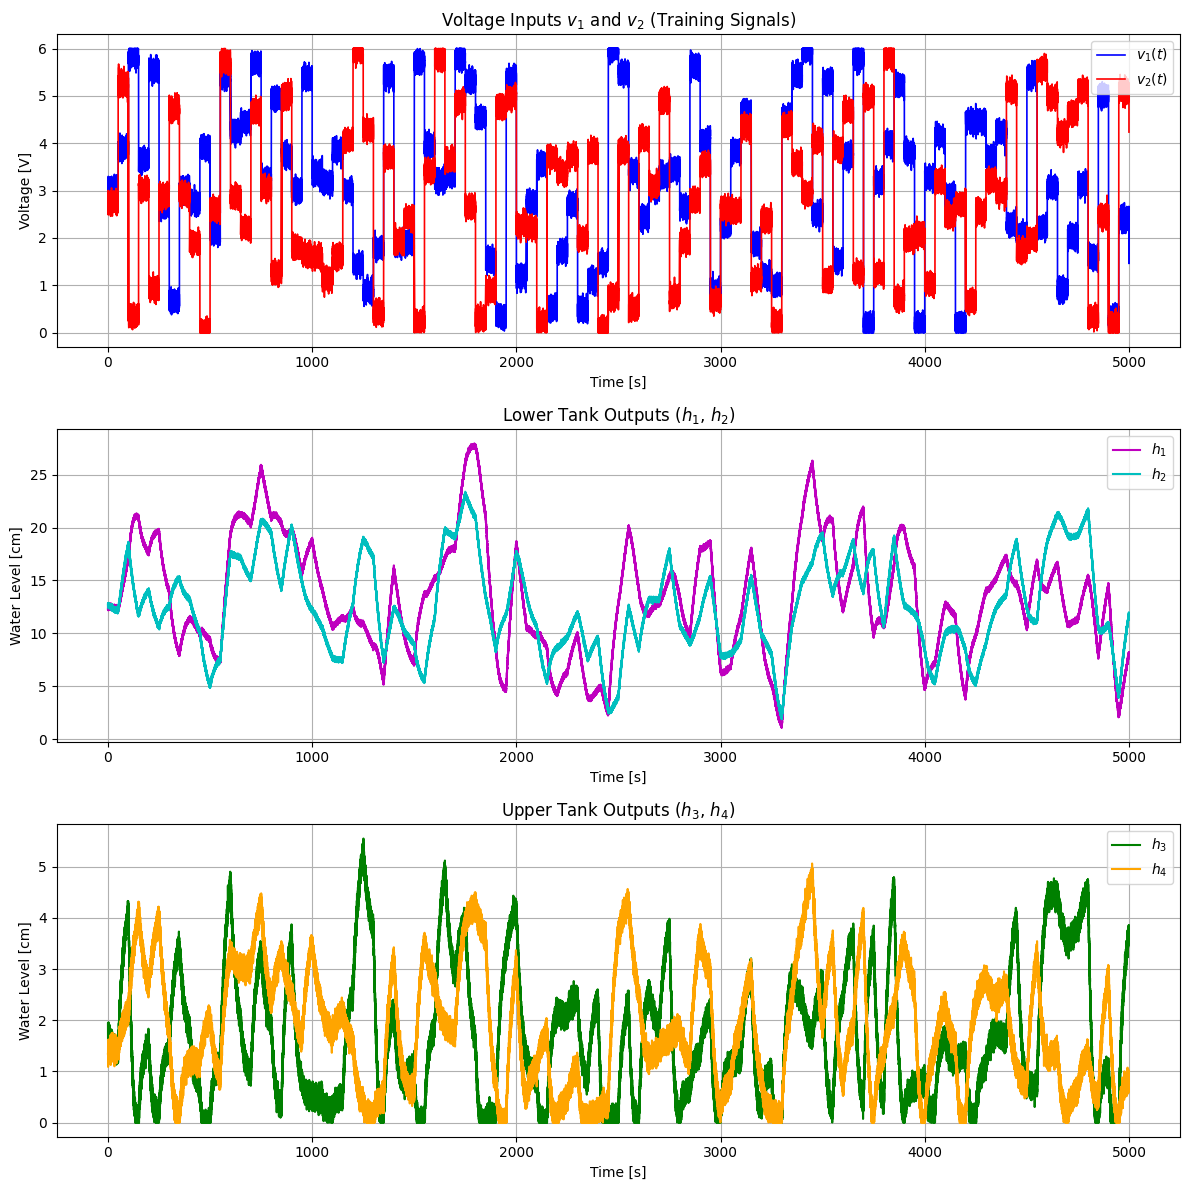

In [8]:
# Creation of the canvas for training signal visualization
plt.figure(figsize=(12, 12))

# Visualization of the input voltages applied to the pumps
plt.subplot(3, 1, 1)
plt.plot(t_full, u_full[:, 0], 'b', linewidth=1.2, label='$v_1(t)$')
plt.plot(t_full, u_full[:, 1], 'r', linewidth=1.2, label='$v_2(t)$')
plt.xlabel('Time [s]')
plt.ylabel('Voltage [V]')
plt.title('Voltage Inputs $v_1$ and $v_2$ (Training Signals)')
plt.legend(loc='upper right')
plt.grid(True)

# Visualization of the dynamic response of the lower tanks
plt.subplot(3, 1, 2)
plt.plot(t_full, h1_full, 'm', linewidth=1.5, label='$h_1$')
plt.plot(t_full, h2_full, 'c', linewidth=1.5, label='$h_2$')
plt.xlabel('Time [s]')
plt.ylabel('Water Level [cm]')
plt.title('Lower Tank Outputs ($h_1$, $h_2$)')
plt.legend(loc='upper right')
plt.grid(True)

# Visualization of the dynamic response of the upper tanks
plt.subplot(3, 1, 3)
plt.plot(t_full, h3_full, 'g', linewidth=1.5, label='$h_3$')
plt.plot(t_full, h4_full, 'orange', linewidth=1.5, label='$h_4$')
plt.xlabel('Time [s]')
plt.ylabel('Water Level [cm]')
plt.title('Upper Tank Outputs ($h_3$, $h_4$)')
plt.legend(loc='upper right')
plt.grid(True)

# Layout adjustment and subplots display
plt.tight_layout()
plt.show()

In [9]:
def kalman_filter(z, Q=1e-5, R=1e-2):
    n = len(z)
    x_hat = np.zeros(n)      # Level estimation
    P = np.zeros(n)          # Error covariance
    x_hat[0] = z[0]
    P[0] = 1.0

    for k in range(1, n):
        # Prediction
        x_hat_minus = x_hat[k-1]
        P_minus = P[k-1] + Q

        # Update
        K = P_minus / (P_minus + R)
        x_hat[k] = x_hat_minus + K * (z[k] - x_hat_minus)
        P[k] = (1 - K) * P_minus
        
    return x_hat

# Application with tuning parameters (Q: process, R: sensor)
h1_full = kalman_filter(h1_full)
h2_full = kalman_filter(h2_full)
h3_full = kalman_filter(h3_full)
h4_full = kalman_filter(h4_full)
u_full[:,0] = kalman_filter(u_full[:,0])
u_full[:,1] = kalman_filter(u_full[:,1])

In [10]:
# Implementation of a linear Koopman model
def lift_func(h_data):
    h_safe = np.maximum(h_data, 1e-6)
    return np.hstack([h_data, np.sqrt(h_safe), np.sin(h_data), np.cos(h_data), h_data ** 2, np.abs(h_data)])

# State stacking and Koopman snapshots generation
h_full = np.column_stack([h1_full, h2_full, h3_full, h4_full]) 
Z = lift_func(h_full)
Z_curr, Z_next, U_curr = Z[:-1], Z[1:], u_full[:-1]

# Construction of the regression matrix with state and input components
X_reg = np.hstack([Z_curr, U_curr])

In [11]:
# Operator identification using Ridge regression to extract A and B matrices
model_koopman = Ridge(alpha=1e-2, fit_intercept=False)
model_koopman.fit(X_reg, Z_next)
W, nz, nu = model_koopman.coef_, Z_curr.shape[1], U_curr.shape[1]

# Extraction of lifted state dynamics and linear control influence matrices
A_k, B_k = W[:, :nz], W[:, nz:]

# Training of output matrix C to map from lifted space Z back to state H
model_output = Ridge(alpha=1e-2, fit_intercept=False)
model_output.fit(Z, h_full)
C_matrix = model_output.coef_

In [12]:
# Recursive linear simulation of the lifted state dynamics
n_steps = len(u_full)
z_sim = np.zeros((n_steps, nz))
z_sim[0] = Z[0]

for k in range(n_steps - 1):
    u = u_full[k]
    # Linear evolution according to the identified Koopman operator
    z_sim[k+1] = A_k @ z_sim[k] + B_k @ u

# Projection from the lifted space back to the original physical state space
h_koopman = (C_matrix @ z_sim.T).T

In [13]:
def calculate_metrics(real, pred):
    # RMSE: Root Mean Square Error magnitude in cm
    rmse = np.sqrt(np.mean((real - pred)**2))

    # MAE: Mean Absolute Error in cm
    mae = np.mean(np.abs(real - pred))

    # VAF: Variance Actually Fraction representing dynamic capture quality (%)
    vaf = max(0, (1 - np.var(real - pred) / np.var(real)) * 100)

    return rmse, mae, vaf

# Metrics calculation for the Koopman identification phase across all tanks
rmse1, mae1, vaf1 = calculate_metrics(h1_noisy, h_koopman[:, 0])
rmse2, mae2, vaf2 = calculate_metrics(h2_noisy, h_koopman[:, 1])
rmse3, mae3, vaf3 = calculate_metrics(h3_noisy, h_koopman[:, 2])
rmse4, mae4, vaf4 = calculate_metrics(h4_noisy, h_koopman[:, 3])

# --- RESULTS CONSOLE REPORT ---
print("\n" + "="*60)
print(f"{'TANK':<12} | {'RMSE [cm]':<12} | {'MAE [cm]':<12} | {'VAF [%]':<10}")
print("-" * 60)
print(f"{'Tank 1 (h1)':<12} | {rmse1:9.4f}    | {mae1:9.4f}    | {vaf1:7.2f}%")
print(f"{'Tank 2 (h2)':<12} | {rmse2:9.4f}    | {mae2:9.4f}    | {vaf2:7.2f}%")
print(f"{'Tank 3 (h3)':<12} | {rmse3:9.4f}    | {mae3:9.4f}    | {vaf3:7.2f}%")
print(f"{'Tank 4 (h4)':<12} | {rmse4:9.4f}    | {mae4:9.4f}    | {vaf4:7.2f}%")
print("="*60 + "\n")


TANK         | RMSE [cm]    | MAE [cm]     | VAF [%]   
------------------------------------------------------------
Tank 1 (h1)  |    0.7087    |    0.5593    |   98.25%
Tank 2 (h2)  |    0.4667    |    0.3637    |   98.86%
Tank 3 (h3)  |    0.3361    |    0.2731    |   93.03%
Tank 4 (h4)  |    0.2542    |    0.2067    |   95.10%



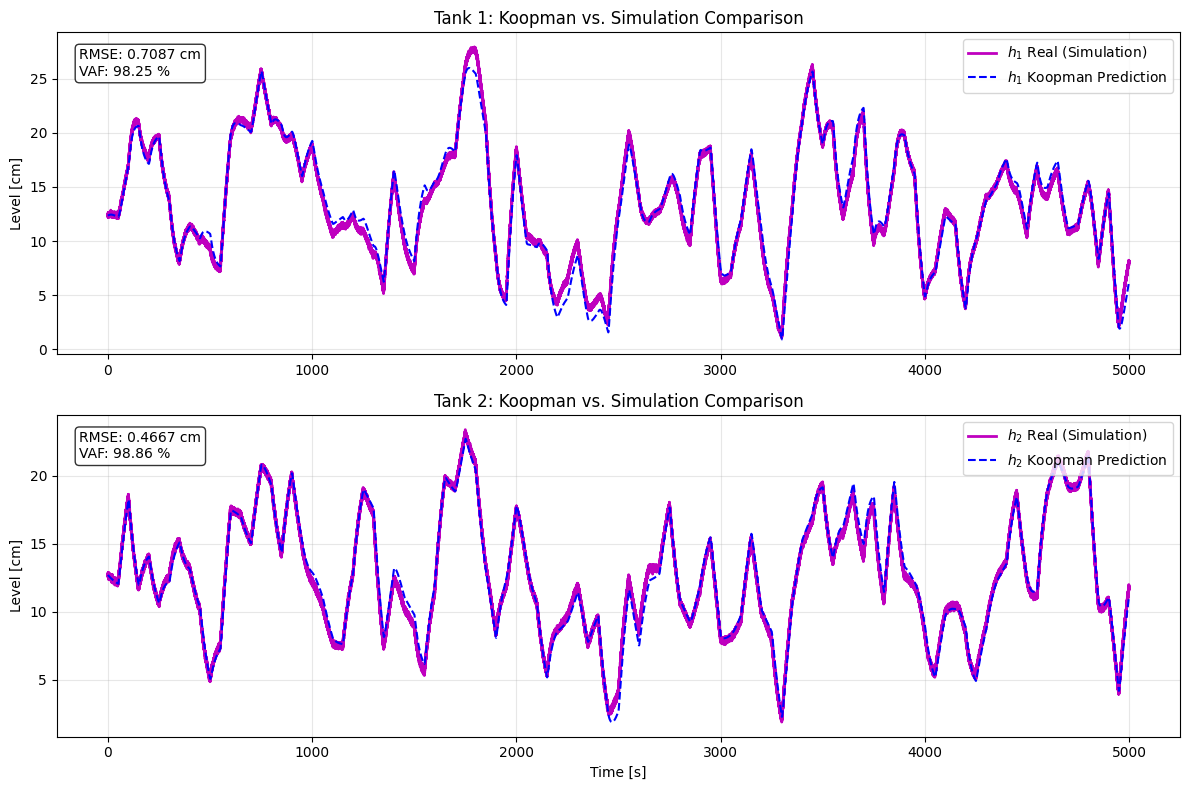

In [14]:
# Results visualization for lower tanks (h1 and h2)
plt.figure(figsize=(12, 8))

# Tank 1: Comparison and performance metrics
plt.subplot(2, 1, 1)
plt.plot(t_full, h1_noisy, 'm', linewidth=2, label='$h_1$ Real (Simulation)')
plt.plot(t_full, h_koopman[:, 0], 'b--', linewidth=1.5, label='$h_1$ Koopman Prediction')
plt.ylabel('Level [cm]')
plt.title('Tank 1: Koopman vs. Simulation Comparison')
textstr1 = '\n'.join((f'RMSE: {rmse1:.4f} cm', f'VAF: {vaf1:.2f} %'))
plt.gca().text(0.02, 0.95, textstr1, transform=plt.gca().transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Tank 2: Comparison and performance metrics
plt.subplot(2, 1, 2)
plt.plot(t_full, h2_noisy, 'm', linewidth=2, label='$h_2$ Real (Simulation)')
plt.plot(t_full, h_koopman[:, 1], 'b--', linewidth=1.5, label='$h_2$ Koopman Prediction')
plt.ylabel('Level [cm]')
plt.xlabel('Time [s]')
plt.title('Tank 2: Koopman vs. Simulation Comparison')
textstr2 = '\n'.join((f'RMSE: {rmse2:.4f} cm', f'VAF: {vaf2:.2f} %'))
plt.gca().text(0.02, 0.95, textstr2, transform=plt.gca().transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

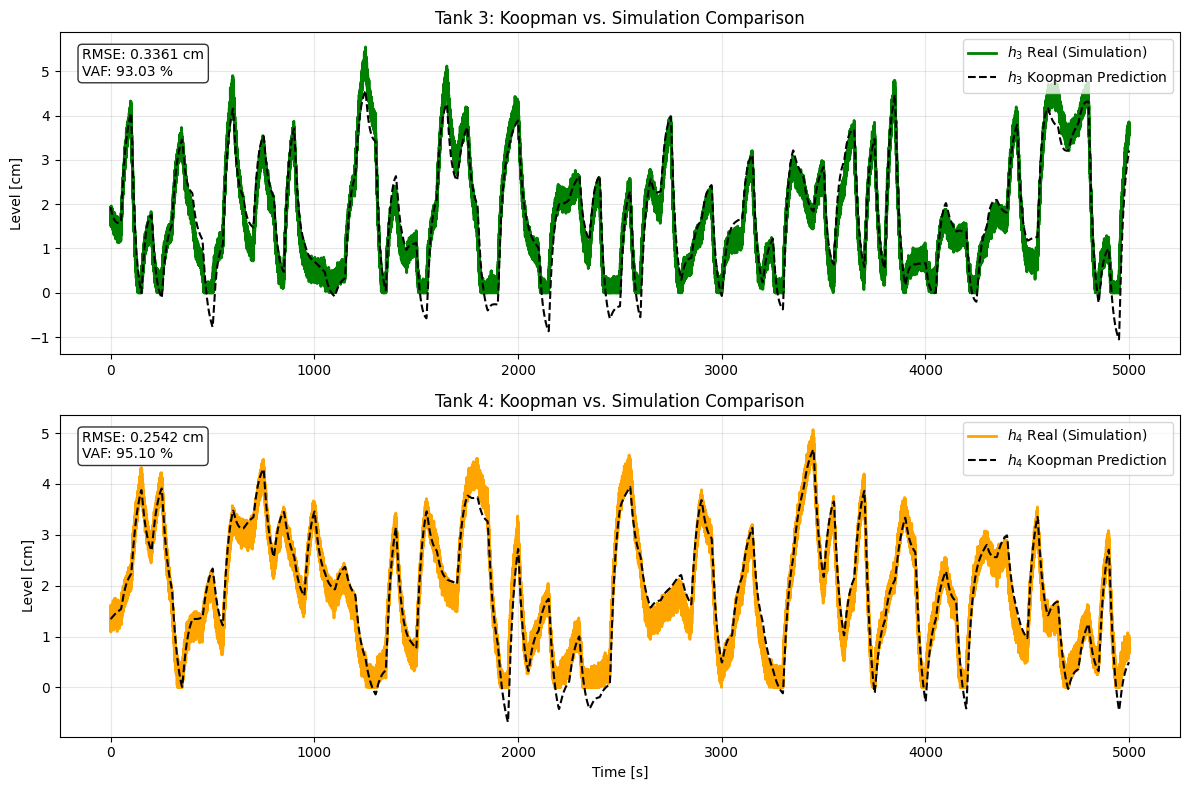

In [15]:
# --- IDENTIFICATION VISUALIZATION: UPPER TANKS ---
plt.figure(figsize=(12, 8))

# Tank 3: Comparison and performance metrics
plt.subplot(2, 1, 1)
plt.plot(t_full, h3_noisy, 'g', linewidth=2, label='$h_3$ Real (Simulation)')
plt.plot(t_full, h_koopman[:, 2], 'k--', linewidth=1.5, label='$h_3$ Koopman Prediction')
plt.ylabel('Level [cm]')
plt.title('Tank 3: Koopman vs. Simulation Comparison')
textstr3 = '\n'.join((f'RMSE: {rmse3:.4f} cm', f'VAF: {vaf3:.2f} %'))
plt.gca().text(0.02, 0.95, textstr3, transform=plt.gca().transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Tank 4: Comparison and performance metrics
plt.subplot(2, 1, 2)
plt.plot(t_full, h4_noisy, 'orange', linewidth=2, label='$h_4$ Real (Simulation)')
plt.plot(t_full, h_koopman[:, 3], 'k--', linewidth=1.5, label='$h_4$ Koopman Prediction')
plt.ylabel('Level [cm]')
plt.xlabel('Time [s]')
plt.title('Tank 4: Koopman vs. Simulation Comparison')
textstr4 = '\n'.join((f'RMSE: {rmse4:.4f} cm', f'VAF: {vaf4:.2f} %'))
plt.gca().text(0.02, 0.95, textstr4, transform=plt.gca().transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# Calculation of the error vector for all four tanks (Koopman vs. Simulation)
error_h1_koopman = h1_noisy - h_koopman[:, 0]
error_h2_koopman = h2_noisy - h_koopman[:, 1]
error_h3_koopman = h3_noisy - h_koopman[:, 2]
error_h4_koopman = h4_noisy - h_koopman[:, 3]

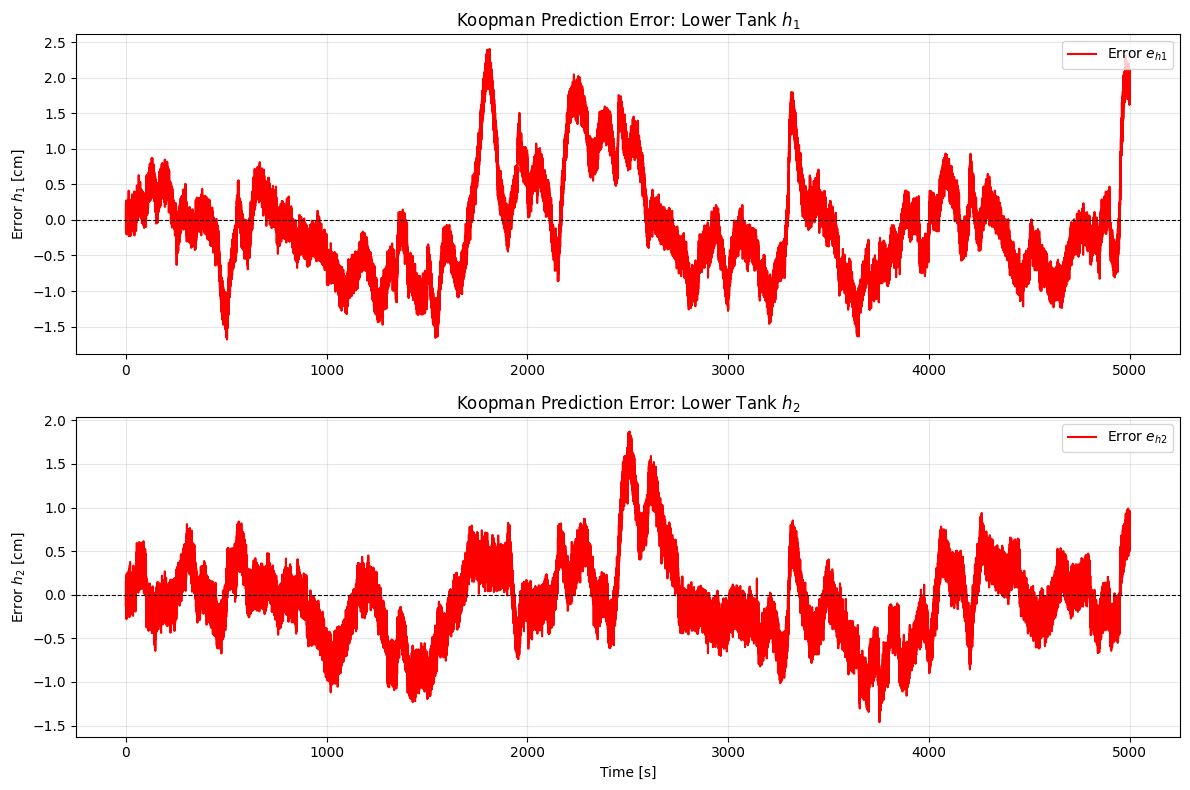

In [17]:
# --- FIGURE: LOWER TANK ERRORS ---
plt.figure(figsize=(12, 8))

# Prediction error for lower tank h1
plt.subplot(2, 1, 1)
plt.plot(t_full, error_h1_koopman, 'r', linewidth=1.5, label='Error $e_{h1}$')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel('Error $h_1$ [cm]')
plt.title('Koopman Prediction Error: Lower Tank $h_1$')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Prediction error for lower tank h2
plt.subplot(2, 1, 2)
plt.plot(t_full, error_h2_koopman, 'r', linewidth=1.5, label='Error $e_{h2}$')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.xlabel('Time [s]')
plt.ylabel('Error $h_2$ [cm]')
plt.title('Koopman Prediction Error: Lower Tank $h_2$')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

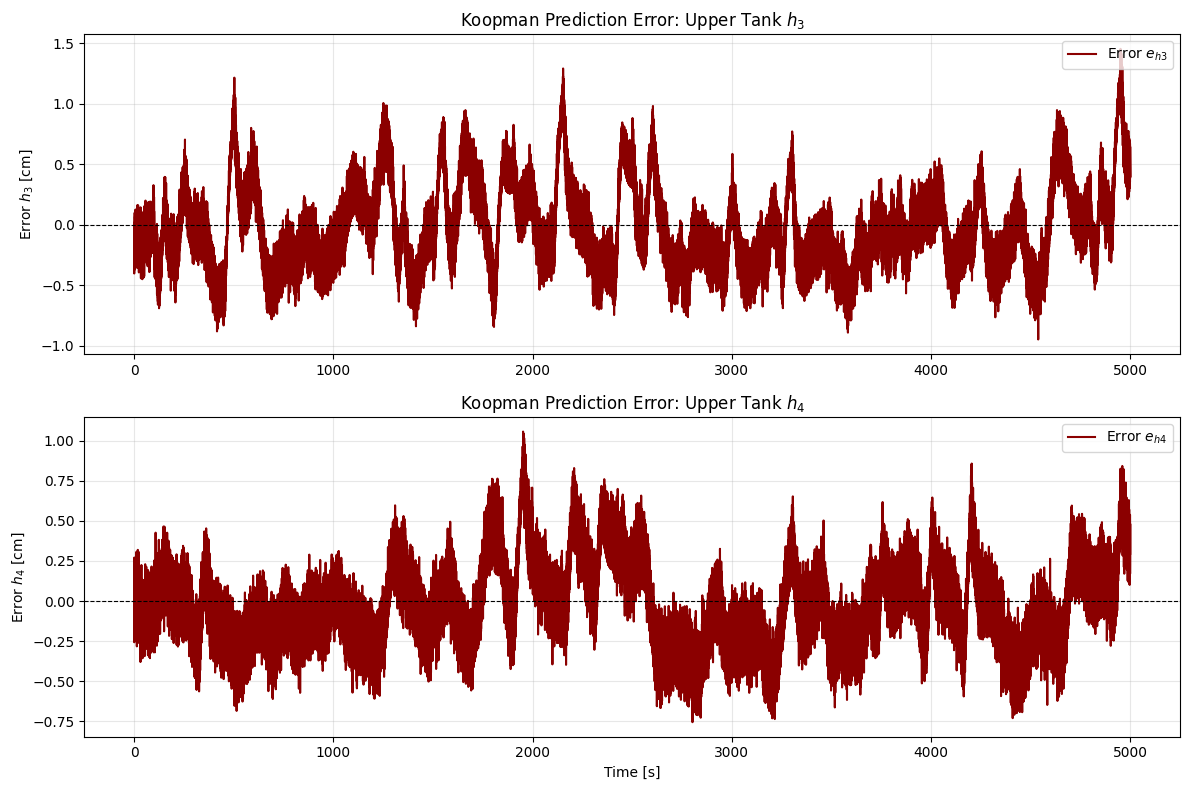

In [18]:
# --- FIGURE: UPPER TANK ERRORS ---
plt.figure(figsize=(12, 8))

# Prediction error for upper tank h3
plt.subplot(2, 1, 1)
plt.plot(t_full, error_h3_koopman, 'darkred', linewidth=1.5, label='Error $e_{h3}$')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel('Error $h_3$ [cm]')
plt.title('Koopman Prediction Error: Upper Tank $h_3$')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Prediction error for upper tank h4
plt.subplot(2, 1, 2)
plt.plot(t_full, error_h4_koopman, 'darkred', linewidth=1.5, label='Error $e_{h4}$')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.xlabel('Time [s]')
plt.ylabel('Error $h_4$ [cm]')
plt.title('Koopman Prediction Error: Upper Tank $h_4$')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# --- GLOBAL STATISTICAL EVALUATION OF THE KOOPMAN MODEL ---

# Concatenation of errors from all four tanks for global metrics
error_full = np.concatenate((error_h1_koopman, error_h2_koopman, error_h3_koopman, error_h4_koopman))

# Calculation of standard error metrics
MSE = np.mean(error_full**2)
RMSE = np.sqrt(MSE)
MAE = np.mean(np.abs(error_full))
SSE = np.sum(error_full**2)

# Calculation of NRMSE (Normalized Root Mean Square Error)
h_real_concat = h_out.flatten()
range_h = np.max(h_real_concat) - np.min(h_real_concat)

NRMSE = RMSE / range_h if range_h != 0 else 0.0

# Display of results with scientific formatting
print("\n" + "="*30 + " KOOPMAN IDENTIFICATION GLOBAL METRICS " + "="*30)
print(f"MSE (Mean Squared Error)\t\t: {MSE:.8e} cm²")
print(f"RMSE (Root Mean Squared Error)\t\t: {RMSE:.8e} cm")
print(f"MAE (Mean Absolute Error)\t\t: {MAE:.8e} cm")
print(f"SSE (Sum of Squared Errors)\t\t: {SSE:.8e} cm²")
print(f"NRMSE (Normalized RMSE)\t\t\t: {NRMSE:.8e} (Dimensionless)")
print("-" * 105)


============================== KOOPMAN IDENTIFICATION GLOBAL METRICS ==============================
MSE (Mean Squared Error)		: 2.24396603e-01 cm²
RMSE (Root Mean Squared Error)		: 4.73705186e-01 cm
MAE (Mean Absolute Error)		: 3.50710848e-01 cm
SSE (Sum of Squared Errors)		: 8.97595390e+04 cm²
NRMSE (Normalized RMSE)			: 1.71313689e-02 (Dimensionless)
---------------------------------------------------------------------------------------------------------


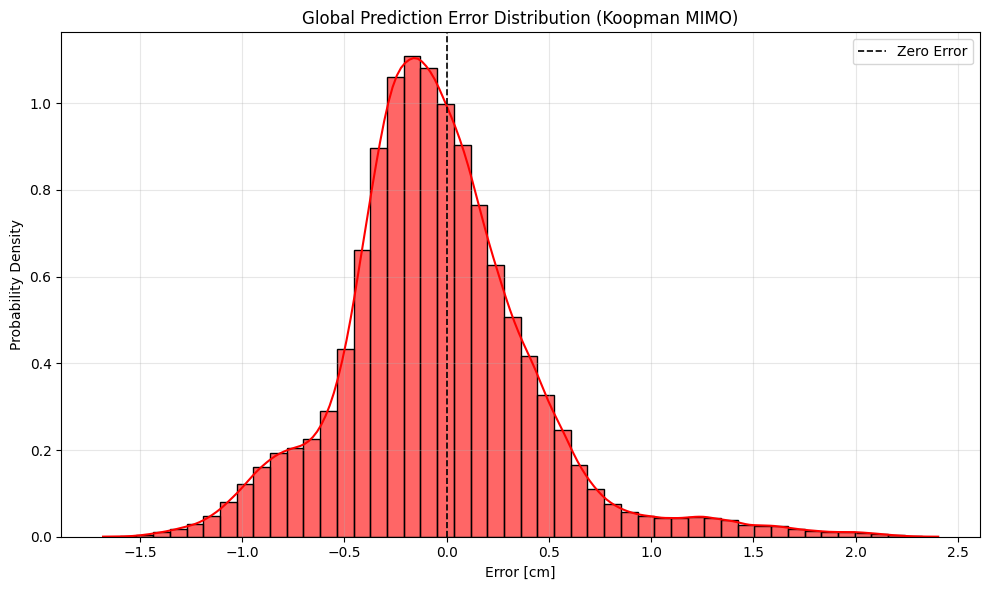

Error Standard Deviation : 0.470938 cm
Mean Error (Bias)        : -0.051125 cm


In [20]:
# --- STATISTICAL ANALYSIS OF ERROR DISTRIBUTION ---
plt.figure(figsize=(10, 6))

# Visualization of the global error density
sns.histplot(error_full, kde=True, color='red', bins=50, stat="density", alpha=0.6)

# Statistical references in the plot
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.2, label='Zero Error')
plt.title('Global Prediction Error Distribution (Koopman MIMO)')
plt.xlabel('Error [cm]')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Dispersion and bias metrics
print(f"Error Standard Deviation : {np.std(error_full):.6f} cm")
print(f"Mean Error (Bias)        : {np.mean(error_full):.6f} cm")